# 06 — CNN and Image Classification with PyTorch

This notebook connects your previous CNN knowledge with PyTorch implementation.

Topics:
- Image tensors and `[N, C, H, W]`
- `nn.Conv2d`
- kernels, filters, stride, padding
- convolution output-size calculation
- ReLU and MaxPool
- feature maps and receptive fields
- flattening
- building a CNN with `nn.Module`
- `torchvision` transforms and augmentation concepts
- `DataLoader`
- complete CNN training/evaluation pipeline
- saving and loading a CNN
- exercises and knowledge check

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.9.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


# 1. Image Tensors

PyTorch CNNs normally use:

```text
Single image: [C, H, W]
Batch:        [N, C, H, W]
```

For an RGB 64×64 image:

```text
[3, 64, 64]
```

For a batch of 32:

```text
[32, 3, 64, 64]
```

Image shape: torch.Size([3, 64, 64])


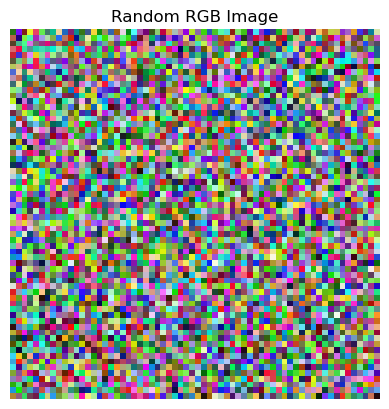

In [2]:
image = torch.rand(3, 64, 64)

print("Image shape:", image.shape)

# Matplotlib expects H x W x C
plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.title("Random RGB Image")
plt.show()

# 2. `Conv2d`

The basic convolution layer is:

```python
nn.Conv2d(in_channels, out_channels, kernel_size)
```

For:

```python
nn.Conv2d(3, 16, 3)
```

we have:

- 3 input channels
- 16 learned filters
- each filter uses a 3×3 kernel

The weight tensor has shape:

```text
[out_channels, in_channels, kernel_height, kernel_width]
```

In [3]:
conv = nn.Conv2d(3, 16, kernel_size=3)

print(conv)
print("Weight shape:", conv.weight.shape)
print("Bias shape:", conv.bias.shape)

print("Total parameters:", sum(p.numel() for p in conv.parameters()))

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
Weight shape: torch.Size([16, 3, 3, 3])
Bias shape: torch.Size([16])
Total parameters: 448


# 3. Convolution Forward Pass

`Conv2d` expects a batch.

```text
Single image:
[3, 64, 64]

Add batch dimension:
[1, 3, 64, 64]
```

In [4]:
x = image.unsqueeze(0)
output = conv(x)

print("Input:", x.shape)
print("Output:", output.shape)

Input: torch.Size([1, 3, 64, 64])
Output: torch.Size([1, 16, 62, 62])


# 4. Convolution Output Size

For one spatial dimension:

```text
Output = floor((Input + 2P - D(K-1) - 1) / S) + 1
```

where:

- `Input` = input size
- `K` = kernel size
- `S` = stride
- `P` = padding
- `D` = dilation

For the common case `D=1`:

```text
Output = floor((Input + 2P - K) / S) + 1
```

In [4]:
def conv_output_size(input_size, kernel_size, stride=1, padding=0, dilation=1):
    return ((input_size + 2*padding - dilation*(kernel_size-1) - 1)
            // stride) + 1

print("3x3, stride 1, padding 0:", conv_output_size(64, 3))
print("3x3, stride 1, padding 1:", conv_output_size(64, 3, padding=1))
print("5x5, stride 2, padding 2:", conv_output_size(64, 5, stride=2, padding=2))

3x3, stride 1, padding 0: 62
3x3, stride 1, padding 1: 64
5x5, stride 2, padding 2: 32


# 5. Padding

With:

```python
kernel_size=3
stride=1
padding=1
```

the spatial size stays the same:

```text
64 × 64
   ↓
Conv 3×3, padding 1
   ↓
64 × 64
```

In [6]:
conv_same = nn.Conv2d(3, 16, kernel_size=3, padding=1)
out = conv_same(x)

print("Input:", x.shape)
print("Output:", out.shape)

Input: torch.Size([1, 3, 64, 64])
Output: torch.Size([1, 16, 64, 64])


# 6. Stride

Stride controls how far the kernel moves.

```text
stride=1 → detailed spatial sampling
stride=2 → spatial dimensions are reduced
```

In [7]:
conv_stride2 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
out = conv_stride2(x)

print("Input:", x.shape)
print("Output:", out.shape)

Input: torch.Size([1, 3, 64, 64])
Output: torch.Size([1, 16, 32, 32])


# 7. ReLU

A common CNN block is:

```text
Conv2d → ReLU
```

ReLU introduces non-linearity:

```text
ReLU(x) = max(0, x)
```

In [8]:
block = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),
    nn.ReLU()
)

features = block(x)

print(features.shape)
print("Minimum activation:", features.min().item())

torch.Size([1, 16, 64, 64])
Minimum activation: 0.0


# 8. Max Pooling

A 2×2 max-pooling layer usually halves height and width:

```text
64 × 64
   ↓
MaxPool2d(2)
   ↓
32 × 32
```

It keeps the strongest activation in each local 2×2 region.

In [9]:
pool = nn.MaxPool2d(2)
pooled = pool(features)

print("Before:", features.shape)
print("After:", pooled.shape)

Before: torch.Size([1, 16, 64, 64])
After: torch.Size([1, 16, 32, 32])


# 9. CNN Feature Hierarchy

A simplified view:

```text
Early layers
    ↓
Edges
    ↓
Corners / textures
    ↓
Parts / shapes
    ↓
Higher-level visual patterns
    ↓
Classification
```

As the network gets deeper, the features generally become more abstract.

# 10. Build a Simple CNN

Architecture:

```text
RGB image
   ↓
Conv → ReLU → Pool
   ↓
Conv → ReLU → Pool
   ↓
Flatten
   ↓
Linear → ReLU → Linear
   ↓
Class logits
```

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN()
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [11]:
dummy = torch.randn(4, 3, 64, 64)

with torch.no_grad():
    features = model.features(dummy)
    logits = model(dummy)

print("Input:", dummy.shape)
print("Features:", features.shape)
print("Logits:", logits.shape)

Input: torch.Size([4, 3, 64, 64])
Features: torch.Size([4, 32, 16, 16])
Logits: torch.Size([4, 10])


# 11. Why Flatten?

Convolution produces:

```text
[N, C, H, W]
```

A linear layer expects:

```text
[N, features]
```

So:

```text
[N, 32, 16, 16]
        ↓
[N, 8192]
```

`nn.Flatten()` performs this conversion.

# 12. Parameter Sharing

A convolution filter is reused across different image locations.

Instead of learning a separate edge detector for every pixel position, one learned filter slides across the image.

This is called **parameter sharing** and is one of the major reasons CNNs are efficient for images.

# 13. Receptive Field

A 3×3 convolution sees a local region.

When convolutional layers are stacked, deeper neurons can depend on increasingly larger regions of the original image.

This effective region is called the neuron's **receptive field**.

# 14. `torchvision`

`torchvision` provides common computer-vision tools:

- datasets
- transforms
- pretrained models
- image utilities

In [12]:
try:
    import torchvision
    print("torchvision:", torchvision.__version__)
except ImportError:
    print("torchvision is not installed.")

torchvision: 0.24.1


# 15. Image Transforms

Typical preprocessing:

```text
Image
  ↓
Resize
  ↓
Convert to Tensor
  ↓
Normalize
  ↓
CNN
```

Common augmentation:

```text
Random crop
Horizontal flip
Small rotation
Color changes
```

Augmentation is generally applied to training data and should preserve the meaning of the label.

Example:

```python
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
```

For a real project, choose normalization statistics and augmentations appropriate to the dataset.

# 16. Synthetic Image Dataset

To keep this notebook self-contained, we will create three visual classes:

- Class 0 → vertical stripe
- Class 1 → horizontal stripe
- Class 2 → bright square

This lets us train a real CNN without downloading a dataset.

In [13]:
torch.manual_seed(42)

def create_pattern_dataset(samples_per_class=400, size=32):
    images, labels = [], []

    for _ in range(samples_per_class):
        img = torch.zeros(3, size, size)
        start = torch.randint(3, size - 8, (1,)).item()
        img[:, :, start:start+4] = 1.0
        img += 0.10 * torch.randn_like(img)
        images.append(img.clamp(0, 1))
        labels.append(0)

    for _ in range(samples_per_class):
        img = torch.zeros(3, size, size)
        start = torch.randint(3, size - 8, (1,)).item()
        img[:, start:start+4, :] = 1.0
        img += 0.10 * torch.randn_like(img)
        images.append(img.clamp(0, 1))
        labels.append(1)

    for _ in range(samples_per_class):
        img = torch.zeros(3, size, size)
        top = torch.randint(3, size - 10, (1,)).item()
        left = torch.randint(3, size - 10, (1,)).item()
        img[:, top:top+8, left:left+8] = 1.0
        img += 0.10 * torch.randn_like(img)
        images.append(img.clamp(0, 1))
        labels.append(2)

    return torch.stack(images), torch.tensor(labels, dtype=torch.long)

X, y = create_pattern_dataset()

print("Images:", X.shape)
print("Labels:", y.shape)

Images: torch.Size([1200, 3, 32, 32])
Labels: torch.Size([1200])


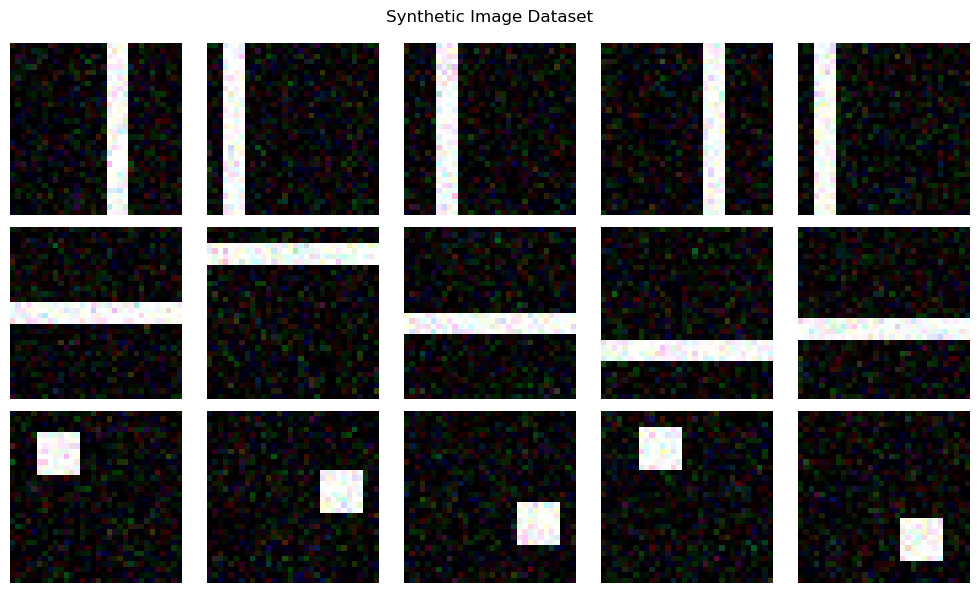

In [14]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for class_id in range(3):
    indices = torch.where(y == class_id)[0][:5]
    for j, idx in enumerate(indices):
        axes[class_id, j].imshow(X[idx].permute(1, 2, 0))
        axes[class_id, j].axis("off")
        if j == 0:
            axes[class_id, j].set_ylabel(f"Class {class_id}")

plt.suptitle("Synthetic Image Dataset")
plt.tight_layout()
plt.show()

# 17. Train / Validation / Test Split

In [15]:
full_dataset = TensorDataset(X, y)

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 840
Validation: 180
Test: 180


In [16]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Image batch: torch.Size([64, 3, 32, 32])
Label batch: torch.Size([64])


# 18. CNN for the Synthetic Dataset

Because our images are 32×32, three 2×2 pooling operations reduce:

```text
32 → 16 → 8 → 4
```

After the final block we have:

```text
64 × 4 × 4
```

features per image.

In [17]:
class PatternCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = PatternCNN()
print(model)

PatternCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [18]:
dummy = torch.randn(8, 3, 32, 32)

with torch.no_grad():
    features = model.features(dummy)
    logits = model(dummy)

print("Input:", dummy.shape)
print("Features:", features.shape)
print("Logits:", logits.shape)

Input: torch.Size([8, 3, 32, 32])
Features: torch.Size([8, 64, 4, 4])
Logits: torch.Size([8, 3])


# 19. Loss, Optimizer, and Device

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Device: cuda
Parameters: 155171


# 20. Training Function

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

# 21. Evaluation Function

In [21]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)

            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

# 22. Train the CNN

In [22]:
num_epochs = 12

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/12 | Train Loss: 0.9256 | Train Acc: 0.6119 | Val Loss: 0.4172 | Val Acc: 0.9222
Epoch 02/12 | Train Loss: 0.2181 | Train Acc: 0.9310 | Val Loss: 0.0288 | Val Acc: 1.0000
Epoch 03/12 | Train Loss: 0.0242 | Train Acc: 0.9952 | Val Loss: 0.0020 | Val Acc: 1.0000
Epoch 04/12 | Train Loss: 0.0020 | Train Acc: 1.0000 | Val Loss: 0.0002 | Val Acc: 1.0000
Epoch 05/12 | Train Loss: 0.0007 | Train Acc: 1.0000 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch 06/12 | Train Loss: 0.0005 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch 07/12 | Train Loss: 0.0002 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch 08/12 | Train Loss: 0.0003 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch 09/12 | Train Loss: 0.0002 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch 10/12 | Train Loss: 0.0004 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch 11/12 | Train Loss: 0.0002 | Train Acc: 1.0000 | Val Loss: 0.0000 | Val Acc: 1.0000
Epoch 12/1

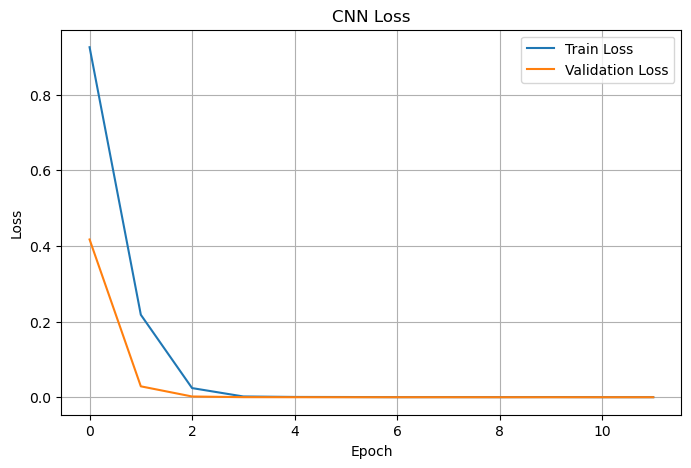

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()
plt.grid(True)
plt.show()

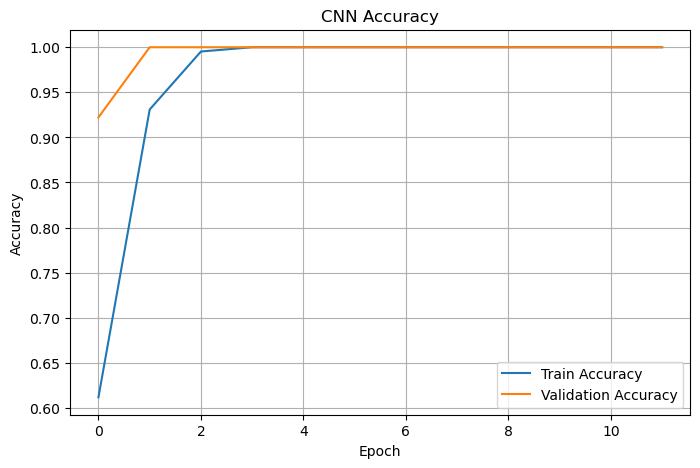

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 23. Test Evaluation

In [25]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0000
Test Accuracy: 1.0000


# 24. Predictions

In [26]:
model.eval()

images, labels = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
    logits = model(images_device)
    predictions = logits.argmax(dim=1)

print("True:     ", labels[:20].numpy())
print("Predicted:", predictions[:20].cpu().numpy())

True:      [0 1 2 2 2 1 2 2 2 2 2 0 0 2 2 0 2 1 2 1]
Predicted: [0 1 2 2 2 1 2 2 2 2 2 0 0 2 2 0 2 1 2 1]


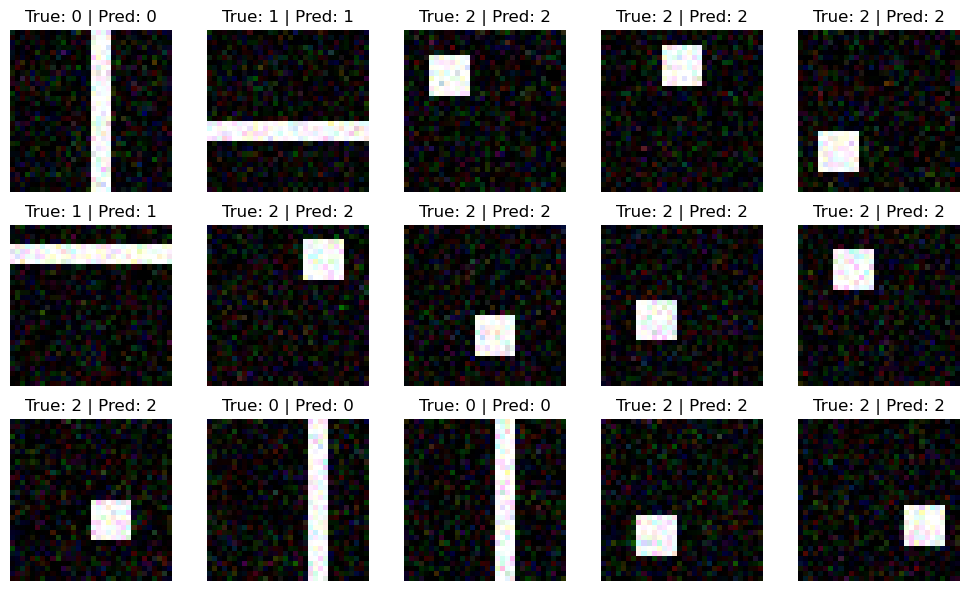

In [27]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1, 2, 0))
    ax.set_title(
        f"True: {labels[i].item()} | Pred: {predictions[i].item()}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

# 25. CNN vs Fully Connected Network

For a 64×64 RGB image:

```text
3 × 64 × 64 = 12,288 values
```

A fully connected network treats these mostly as a long vector.

A CNN instead exploits spatial structure:

```text
Pixels
  ↓
Local patterns
  ↓
Feature maps
  ↓
Higher-level patterns
  ↓
Classification
```

CNNs also reuse convolution weights across spatial locations.

# 26. Why Increase Channels?

A common progression is:

```text
3 → 32 → 64 → 128 channels
```

while spatial resolution decreases:

```text
224×224 → 112×112 → 56×56 → ...
```

Conceptually:

```text
Earlier: simple features + many locations
Later:   richer features + fewer locations
```

# 27. Pooling vs Strided Convolution

Both can reduce spatial resolution.

Pooling:

```python
nn.MaxPool2d(2)
```

Strided convolution:

```python
nn.Conv2d(..., stride=2)
```

Modern architectures use different combinations depending on their design.

# 28. Connection to YOLO

A simplified classification pipeline is:

```text
Image
  ↓
CNN feature extraction
  ↓
Classification head
  ↓
Class logits
```

A simplified object-detection pipeline is:

```text
Image
  ↓
Feature extraction
  ↓
Detection head
  ↓
Boxes + Classes + Confidence
```

YOLO is therefore not simply "a combination of CNNs." It is an object-detection architecture/framework that uses learned visual feature extraction plus detection-specific components. Modern YOLO versions can also contain non-CNN components.

# 29. Common CNN Shape Mistakes

### Mistake 1
Using `[H, W, C]` directly.

PyTorch expects:

```text
[C, H, W]
```

for one image and:

```text
[N, C, H, W]
```

for a batch.

### Mistake 2
Wrong `in_channels`.

RGB → `3`

Grayscale → `1`

### Mistake 3
Wrong flattened dimension before `Linear`.

Trace the feature tensor shape before defining the linear layer.

# 30. Common Training Mistakes

- Forgetting `model.train()`
- Forgetting `model.eval()`
- Forgetting `torch.no_grad()` during evaluation
- Applying Softmax before `CrossEntropyLoss`
- Using the wrong target dtype
- Applying inappropriate augmentation
- Test-data leakage
- Excessively large fully connected layers
- Model and tensors being on different devices

# 31. Save the CNN

In [28]:
torch.save(model.state_dict(), "pattern_cnn.pth")
print("Model saved.")

Model saved.


# 32. Load the CNN

In [29]:
loaded_model = PatternCNN(num_classes=3)
loaded_model.load_state_dict(
    torch.load("pattern_cnn.pth", map_location=device)
)
loaded_model.to(device)
loaded_model.eval()

print("Model loaded successfully.")

Model loaded successfully.


# 33. Knowledge Check

1. What shape does PyTorch expect for a batch of RGB images?
2. What does `in_channels` mean?
3. What does `out_channels` mean?
4. What does kernel size control?
5. What does stride do?
6. What does padding do?
7. Why use pooling?
8. What is parameter sharing?
9. Why flatten convolutional features?
10. Why is Softmax normally not placed before `CrossEntropyLoss`?

# 34. Key Takeaways

The core CNN pipeline is:

```text
Image
  ↓
Conv2d
  ↓
ReLU
  ↓
Pooling
  ↓
Conv2d
  ↓
ReLU
  ↓
Pooling
  ↓
Flatten
  ↓
Linear
  ↓
Logits
  ↓
CrossEntropyLoss
```

The key PyTorch image format is:

```text
[Batch, Channels, Height, Width]
```

You now have the foundation for practical computer vision with PyTorch.